### Deep learning clasification model

In [ ]:
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.colors import CenteredNorm
from sklearn.metrics import classification_report, r2_score, jaccard_score, confusion_matrix, cohen_kappa_score
import seaborn as sns

from io import BytesIO
from openpyxl import load_workbook
from openpyxl.drawing.image import Image

import json

In [31]:
target_res = 0.125
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
min_time, max_time = pd.to_datetime("2013-01-01"), pd.to_datetime("2025-12-31")

sp = "SQA"
fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp=sp)
fishing = fishing_ds["CPUE_class"]
fishing = fishing.fillna(0)

effort = xr.open_dataset(f"../data/processed/targets/esfuerzo_{target_res}.nc")
effort = effort["Horas"]/24
effort = effort.fillna(0)

mask_ds = xr.open_dataset(f"../data/processed/static/area_pesca_{target_res}.nc")
mask = mask_ds["mask"]
mask = mask.fillna(0)
mask = mask.broadcast_like(fishing)

temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp = temp_ds["to"]
temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom_ds = temp_bottom_ds.rename({"to": "to_b"})
temp_bottom = temp_bottom_ds["to_b"]
temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed = mixed_ds["mlotst"]
mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth = depth_ds["depth"] 
depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo = zo_ds["zo"]
zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so = so_ds["so"]
so = (so - so.mean()) / so.std()
so = so.fillna(0)

ugo_ds = xr.open_dataset("../data/processed/dynamic/ugo_surface.nc")
ugo = ugo_ds["ugo"]
ugo = (ugo - ugo.mean()) / ugo.std()
ugo = ugo.fillna(0)

vgo_ds = xr.open_dataset("../data/processed/dynamic/vgo_surface.nc")
vgo = vgo_ds["vgo"]
vgo = (vgo - vgo.mean()) / vgo.std()
vgo = vgo.fillna(0)

pp = xr.open_dataset("../data/processed/dynamic/pp.nc")
pp = pp["PP"]
pp = (pp - pp.mean()) / pp.std()
pp = pp.fillna(0)

cdm = xr.open_dataset("../data/processed/dynamic/cdm.nc")
cdm = cdm["CDM"]
cdm = (cdm - cdm.mean()) / cdm.std()
cdm = cdm.fillna(0)

spm = xr.open_dataset("../data/processed/dynamic/spm.nc")
spm = spm["SPM"]
spm = (spm - spm.mean()) / spm.std()    
spm = spm.fillna(0)

zsd = xr.open_dataset("../data/processed/dynamic/zsd.nc")
zsd = zsd["ZSD"]
zsd = (zsd - zsd.mean()) / zsd.std()
zsd = zsd.fillna(0)


month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month_sin.name = "month_sin"
month_cos.name = "month_cos"
month = month.broadcast_like(temp)

year = temp["time"].dt.year
year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)

lat = (temp["lat"] - temp["lat"].mean()) / temp["lat"].std()
lon = (temp["lon"] - temp["lon"].mean()) / temp["lon"].std()
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp)

temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, ugo, vgo, pp, cdm, spm, zsd = xr.align(
    temp, temp_bottom, chl, mixed, depth, month_sin, month_cos, lat, lon, zo, so, month, year, vgo, ugo, pp, cdm, spm, zsd, join="inner")

fishing, effort, mask = xr.align(fishing, effort, mask, join="inner")


#area de pesca y un poco alrededor
croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)

# area global
cropped = lambda da: da.sel(
    lon=slice(min_lon-0, max_lon+2),
    lat=slice(min_lat-4, max_lat+1),
    time=slice(min_time, max_time)
)

fishing = croppedT(fishing)
effort = croppedT(effort)    
mask = croppedT(mask)

temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
ugo = cropped(ugo)
vgo = cropped(vgo)
pp = cropped(pp)
cdm = cropped(cdm)
spm = cropped(spm)
zsd = cropped(zsd)

In [ ]:
y = fishing
y = y.transpose("time", "lat", "lon")

m = mask 
m = m.transpose("time", "lat", "lon")


vars_ = [temp, #temp_bottom,
        #so, zo,
        ugo, vgo, mixed,
        cdm, #chl, pp,
        month_sin, month_cos,
        # moon_phase,
        # lat, lon,
        # depth,
        ]

vars_names = [v.name for v in vars_]
in_channels = len(vars_)
X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")
print(X.shape)
print(y.shape)
print(m.shape)

split_year = 2022

train_X = X.sel(time=slice(None, f"{split_year-1}-12-31"))
test_X  = X.sel(time=slice(f"{split_year}-01-01", None))

train_y = y.sel(time=slice(None, f"{split_year-1}-12-31"))
test_y  = y.sel(time=slice(f"{split_year}-01-01", None))

m_train = m.sel(time=slice(None, f"{split_year-1}-12-31"))
m_test  = m.sel(time=slice(f"{split_year}-01-01", None))


# -------- Check inflation factor --------
X_np = train_X.values  # (time, channel, lat, lon)
t, c, h, w = X_np.shape
X_flat = X_np.reshape(t, c, -1)       # (time, channel, pixels)
X_flat = X_flat.transpose(0, 2, 1)    # (time, pixels, channel)
X_flat = X_flat.reshape(-1, c)        # (samples, channel)
df = pd.DataFrame(X_flat, columns=vars_names)
vif_data = pd.DataFrame()
vif_data["feature"] = df.columns
vif_data["VIF"] = [variance_inflation_factor(df.values, i)for i in range(df.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))

def create_windows(X, y, m, window=12):
    X_data = X.values   # (time, channels, H, W)
    y_data = y.values   # (time, H, W)
    m_data = m.values   # (time, H, W)

    X_seq, y_seq, m_seq= [], [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window]) #12 months
        y_seq.append(y_data[i+window]) #next month
        m_seq.append(m_data[i+window]) #next month
        

    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_seq), dtype=torch.float32),
    )

window = 12 #12 months

X_train, y_train, m_train = create_windows(train_X, train_y, m_train, window)
X_test, y_test, m_test = create_windows(test_X, test_y, m_test, window)

print(X_train.shape)  # (N, T, C, H, W)
print(y_train.shape)  # (N, H, W)
print(m_train.shape)  # (N, H, W)
###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train, m_train),
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test, m_test),
    batch_size=batch_size,
    shuffle=False
)

(156, 10, 62, 25)
(156, 30, 17)
(156, 30, 17)
     feature       VIF
3       to_b  6.029587
0         to  5.412759
2         zo  5.076337
1         so  4.464471
8  month_sin  3.858012
4        vgo  2.905017
6     mlotst  2.687445
9  month_cos  2.515059
5        ugo  2.264029
7        CDM  1.199297
torch.Size([96, 12, 10, 62, 25])
torch.Size([96, 30, 17])
torch.Size([96, 30, 17])


In [33]:
# -------- UNet 3D blocks--------

# -------- Basic Conv Block --------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.PReLU(out_ch),
            nn.Dropout3d(0.25),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.PReLU(out_ch)
            )

    def forward(self, x):
        return self.block(x)

# -------- Decoder Block --------
class DecoderBlock3D(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose3d(in_channels, out_channels, (1, 2, 2), stride=(1, 2, 2))
        self.conv_block = ConvBlock(out_channels + skip_channels, out_channels)
        
    def forward(self, x, skip):
        x = self.up(x)

        # Handle size mismatches
        x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)

        x = self.conv_block(x)
        return x

# -------- Temporal Aggregation Block --------
class TemporalAggregationBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.temporal_attn = nn.Sequential(
            nn.Conv3d(in_channels, in_channels, kernel_size=(3, 1, 1), padding=(1, 0, 0), groups=in_channels),
            nn.Sigmoid()
        )
        self.temporal_score = nn.Conv3d(in_channels, 1, kernel_size=1)
    
    def forward(self, x):
        # x shape: (B, C, T, H, W)
        attn = self.temporal_attn(x)
        feat = x * attn
        score = self.temporal_score(feat)
        weights = torch.softmax(score, dim=2) 
        feat = (feat * weights).sum(dim=2)    
        return feat

# -------- Global Attention Branch --------
class GlobalAttentionBranch(nn.Module):
    def __init__(self, channels, time_pooling=None):
        super().__init__()
        reduction = max(channels // 4, 8)
        self.branch = nn.Sequential(
            nn.AdaptiveAvgPool3d((time_pooling, 1, 1)),
            nn.Conv3d(channels, reduction, 1),
            nn.PReLU(reduction),
            nn.Conv3d(reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.branch(x)
    
# -------- Temporal Mixing Block --------
class TemporalMixBlock(nn.Module):
    def __init__(self, channels, window_size=5):
        super().__init__()
        
        # Enforce odd window size to ensure symmetric padding across time
        if window_size % 2 == 0:
            raise ValueError(f"window_size must be odd (3, 5, 7), got {window_size}")
        pad_t = window_size // 2

        self.mix = nn.Sequential(
            nn.Conv3d(channels, channels, kernel_size=(window_size, 1, 1), padding=(pad_t, 0, 0)),
            nn.BatchNorm3d(channels),
            nn.PReLU(channels)
        )

    def forward(self, x):
        return x + self.mix(x)


In [34]:
# -------- U-Net 3D temporal collapse after bottleneck --------
class UNet3D(nn.Module):
    def __init__(self, in_channels, out_hw, out_channels=1, base_ch=10):
        super().__init__()

        self.out_hw = out_hw  # (H, W)

        # -------- Encoder --------
        self.enc1 = ConvBlock(in_channels, base_ch)
        self.pool1 = nn.MaxPool3d((1, 2, 2))

        self.enc2 = ConvBlock(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d((1, 2, 2)) # (1, 2, 2) for no temporal downsampling

        # -------- Bottleneck --------
        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 4)
        self.temp_mix = TemporalMixBlock(base_ch * 4, window_size=7)
        self.global_att = GlobalAttentionBranch(base_ch * 4)
        
        # -------- Decoder --------
        self.decoder2 = DecoderBlock3D(base_ch * 4, base_ch * 2, base_ch * 2)
        self.decoder1 = DecoderBlock3D(base_ch * 2, base_ch, base_ch)
    
        # -------- Temporal Aggregation --------
        self.temporal_agg = TemporalAggregationBlock(base_ch)

        # -------- Classifier Head --------
        self.classifier = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.PReLU(base_ch),
            nn.Conv2d(base_ch, 3, 1)  
        )

    def forward(self, x, mask=None):
        # INPUT COMES AS: (B, T, C, H, W) Convert to:(B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        
        # -------- Encoder --------
        s1 = self.enc1(x)
        p1 = self.pool1(s1)

        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # -------- Bottleneck --------
        b = self.bottleneck(p2)
        # b = self.temp_mix(b)     
        # b = b * self.global_att(b)

        # -------- Decoder --------
        d2 = self.decoder2(b, s2)
        d1 = self.decoder1(d2, s1)

        # -------- Temporal Aggregation --------
        final_2d = self.temporal_agg(d1)
        
        # -------- Classifier Head --------
        logits = self.classifier(final_2d)
        
        # interpolate to output shape      
        logits = F.interpolate(logits, size=self.out_hw, mode="bilinear", align_corners=False)

        if mask is not None:
            # Match out shape: (B, 1, H, W)
            logits = logits * mask.unsqueeze(1).float()
        return logits

In [35]:
class StackedCNN3D(nn.Module):
    def __init__(self, in_channels, out_hw, out_channels=1, base_ch=10):
        super().__init__()
        
        self.out_hw = out_hw  # (H, W)
        
        # --- Stage 1: Low-Level Feature Extraction ---
        # Processes raw environmental inputs at full resolution
        self.stage1 = ConvBlock(in_channels, base_ch)
        self.temp_mix1 = TemporalMixBlock(base_ch, window_size=5)
        
        # --- Stage 2: Contextual & Attention Mapping ---
        # Elevates channel capacity to capture joint environmental correlations
        self.stage2 = ConvBlock(base_ch, base_ch * 2)
        self.global_att = GlobalAttentionBranch(base_ch * 2)
        
        # --- Stage 3: Feature Refinement ---
        # Brings channels back down and smooths features before collapsing time
        self.stage3_1 = ConvBlock(base_ch * 2, base_ch*4)
        self.stage3 = ConvBlock(base_ch * 4, base_ch*2)
        self.stage3_2 = ConvBlock(base_ch*2, base_ch)
        
        # --- Temporal Aggregation ---
        # Your learned softmax mechanism to collapse the 12 months down to 2D
        self.temporal_agg = TemporalAggregationBlock(base_ch)
        
        # -------- Classifier Head --------
        self.classifier = nn.Sequential(
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.PReLU(base_ch),
            nn.Conv2d(base_ch, 3, 1)  
        )

    def forward(self, x, mask=None):
        # Input shape: (B, T, C, H, W) -> Convert to: (B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        
        # --- Forward Stage 1 ---
        x = self.stage1(x)
        # x = self.temp_mix1(x)  # Mixes local temporal neighborhoods
        
        # --- Forward Stage 2 ---
        x = self.stage2(x)
        # Apply global attention gate across the full spatial resolution
        # x = x * self.global_att(x)
        
        # --- Forward Stage 3 ---
        x = self.stage3_1(x)
        x = self.stage3(x)
        x = self.stage3_2(x)
        
        
        # --- Collapse Time Dimension ---
        final_2d = self.temporal_agg(x)  # Results in (B, C, H, W)
        
        # -------- Classifier Head --------
        logits = self.classifier(final_2d)
        
        # interpolate to output shape      
        logits = F.interpolate(logits, size=self.out_hw, mode="bilinear", align_corners=False)

        if mask is not None:
            # Match out shape: (B, 1, H, W)
            logits = logits * mask.unsqueeze(1).float()
        return logits

In [36]:
def ce_ssim_loss(
    logits,
    targets,
    mask,          
    weights=None,
    ssim_weight=0.2,
    window_size=11 
):
    # Ensure mask is float for multiplication
    mask = mask.float()
    
    # -------------------------
    # 1. Cross entropy (Masked)
    # -------------------------
    # Use reduction='none' to get the per-pixel loss: shape (B, H, W)
    ce_unreduced = F.cross_entropy(
        logits,
        targets.long(),
        weight=weights,
        reduction="none" 
    )
    
    # Multiply by mask and take the mean over valid pixels only
    valid_pixels = mask.sum() + 1e-8 # Add epsilon to avoid division by zero
    ce = (ce_unreduced * mask).sum() / valid_pixels

    # -------------------------
    # 2. Convert to probabilities
    # -------------------------
    probs = F.softmax(logits, dim=1)

    # One-hot targets
    num_classes = logits.shape[1]

    target_onehot = F.one_hot(
        targets.long(),
        num_classes=num_classes
    ).permute(0, 3, 1, 2).float()

    # -------------------------
    # 3. SSIM (Masked)
    # -------------------------
    pad = window_size // 2

    mu_p = F.avg_pool2d(probs, window_size, 1, pad)
    mu_t = F.avg_pool2d(target_onehot, window_size, 1, pad)

    sigma_p = F.avg_pool2d(probs**2, window_size, 1, pad) - mu_p**2
    sigma_t = F.avg_pool2d(target_onehot**2, window_size, 1, pad) - mu_t**2
    sigma_pt = (
        F.avg_pool2d(probs * target_onehot, window_size, 1, pad)
        - mu_p * mu_t
    )

    C1 = 0.01**2
    C2 = 0.03**2

    ssim_map = (
        (2 * mu_p * mu_t + C1) *
        (2 * sigma_pt + C2)
    ) / (
        (mu_p**2 + mu_t**2 + C1) *
        (sigma_p + sigma_t + C2)
    )
    
    # ssim_map is (B, C, H, W), mask is (B, H, W)
    # Expand mask to (B, 1, H, W) so it broadcasts across classes
    mask_expanded = mask.unsqueeze(1)
    
    # Apply mask and compute mean over valid regions
    ssim_map_masked = ssim_map * mask_expanded
    valid_pixels_ssim = mask_expanded.sum() * num_classes + 1e-8
    ssim_loss = 1.0 - (ssim_map_masked.sum() / valid_pixels_ssim)

    # -------------------------
    # 4. Final loss
    # -------------------------
    return ce + ssim_weight * ssim_loss

In [37]:
class CESpatialLoss(nn.Module):
    def __init__(self, window_size=11): 
        super().__init__()
        self.window_size = window_size
        
        # Create a uniform 2D window for spatial context tracking
        self.register_buffer(
            "window", 
            torch.ones(1, 1, window_size, window_size) / (window_size ** 2)
        )

    def forward(self, pred, target, mask, weights=None, ssim_weight=0.5):
        """
        pred:    (B, C, H, W) - Raw logits from the model (e.g., C=3 classes)
        target:  (B, H, W)    - Class labels (automatically converted to Long)
        mask:    (B, H, W)    - Binary mask (1 for valid, 0 for ignore)
        weights: (C,)         - Optional class weights for Cross Entropy
        """
        # FIX: Explicitly cast target to Long to prevent the RuntimeError
        target = target.long()
        mask_float = mask.float()
        
        # 1. Masked Cross-Entropy Loss
        ce_loss = F.cross_entropy(pred, target, weight=weights, reduction='none')
        masked_ce = (ce_loss * mask_float).sum() / (mask_float.sum() + 1e-8)
        
        # 2. Fully Differentiable Masked SSIM (on Probabilities)
        ssim_loss = self._differentiable_ssim(pred, target, mask_float)
        
        return masked_ce + (ssim_weight * ssim_loss)

    def _differentiable_ssim(self, pred, target, mask):
        B, C, H, W = pred.shape
        
        # Convert logits to probabilities
        probs = F.softmax(pred, dim=1)
        
        # Convert targets to one-hot encoding (B, C, H, W)
        target_oh = F.one_hot(target, num_classes=C).permute(0, 3, 1, 2).float()
        
        # Reshape to treat each class channel as an independent grayscale image for SSIM
        probs = probs.reshape(B * C, 1, H, W)
        target_oh = target_oh.reshape(B * C, 1, H, W)
        
        # Expand the mask to match the C channels
        mask_expanded = mask.unsqueeze(1).repeat(1, C, 1, 1).reshape(B * C, 1, H, W)
        
        # Probabilities and one-hot vectors always have a data range of exactly [0, 1]
        data_range = 1.0 
        C1 = (0.01 * data_range) ** 2
        C2 = (0.03 * data_range) ** 2

        pad = self.window_size // 2

        # Calculate means
        mu1 = F.conv2d(probs, self.window, padding=pad)[:, :, :H, :W]
        mu2 = F.conv2d(target_oh, self.window, padding=pad)[:, :, :H, :W]

        mu1_sq, mu2_sq, mu1_mu2 = mu1 ** 2, mu2 ** 2, mu1 * mu2

        # Calculate variances
        sigma1_sq = F.conv2d(probs * probs, self.window, padding=pad)[:, :, :H, :W] - mu1_sq
        sigma2_sq = F.conv2d(target_oh * target_oh, self.window, padding=pad)[:, :, :H, :W] - mu2_sq
        sigma12 = F.conv2d(probs * target_oh, self.window, padding=pad)[:, :, :H, :W] - mu1_mu2

        # SSIM map calculation
        ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / \
                   ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
        
        # Apply mask to SSIM map safely
        masked_ssim = (ssim_map * mask_expanded).sum() / (mask_expanded.sum() + 1e-8)
        
        # Minimize loss -> return 1 - SSIM
        return 1.0 - masked_ssim

----------------------------------------------------Iteration 1/10-----------------------------------------------------------------------
1/300 | Loss: 2.695 | Train F1: 0.122 | Val F1: 0.251 | Best F1: 0.251 | F1_1: 0.000 | F1_2: 0.251 | p1: 0.000 r1: 0.000 | p2: 0.144 r2: 1.000
2/300 | Loss: 2.588 | Train F1: 0.140 | Val F1: 0.251 | Best F1: 0.251 | F1_1: 0.000 | F1_2: 0.251 | p1: 0.000 r1: 0.000 | p2: 0.144 r2: 1.000
3/300 | Loss: 2.527 | Train F1: 0.149 | Val F1: 0.251 | Best F1: 0.251 | F1_1: 0.000 | F1_2: 0.251 | p1: 0.000 r1: 0.000 | p2: 0.144 r2: 1.000
4/300 | Loss: 2.465 | Train F1: 0.192 | Val F1: 0.251 | Best F1: 0.251 | F1_1: 0.000 | F1_2: 0.251 | p1: 0.000 r1: 0.000 | p2: 0.144 r2: 1.000
5/300 | Loss: 2.425 | Train F1: 0.199 | Val F1: 0.283 | Best F1: 0.283 | F1_1: 0.000 | F1_2: 0.283 | p1: 0.000 r1: 0.000 | p2: 0.165 r2: 0.992
6/300 | Loss: 2.406 | Train F1: 0.223 | Val F1: 0.300 | Best F1: 0.300 | F1_1: 0.000 | F1_2: 0.300 | p1: 0.000 r1: 0.000 | p2: 0.183 r2: 0.822
7/30

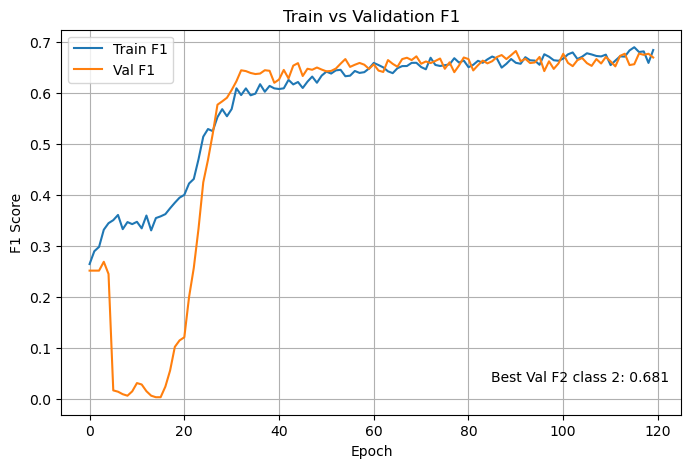

In [ ]:
def compute_metrics_multiclass(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),

        # Class 1
        "precision_1": precision_score(y_true, y_pred, labels=[1], average="micro", zero_division=0),
        "recall_1": recall_score(y_true, y_pred, labels=[1], average="micro", zero_division=0),
        "f1_1": f1_score(y_true, y_pred, labels=[1], average="micro", zero_division=0),

        # Class 2
        "precision_2": precision_score(y_true, y_pred, labels=[2], average="micro", zero_division=0),
        "recall_2": recall_score(y_true, y_pred, labels=[2], average="micro", zero_division=0),
        "f1_2": f1_score(y_true, y_pred, labels=[2], average="micro", zero_division=0),
    }


dry_run=False

iters = 10
list_of_F1_train = []
list_of_F1_val = []
list_of_train_loss = []
list_of_val_loss = []

for i in range(iters):
    if dry_run:
        print("no run")
        break
    print(f"----------------------------------------------------Iteration {i+1}/{iters}-----------------------------------------------------------------------")

    
    out_hw = y_train.shape[1:]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = UNet3D(in_channels=in_channels, out_hw=out_hw, base_ch=10).to(device)
    model_name = model.__class__.__name__
    best_model_path = f"./modelos/runs/Classification/{model_name}_{i+1}.pth"

    loss_func = CESpatialLoss(window_size=7).to(device) 

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.2, patience=40)
    weights = torch.tensor([1.0, 1.0, 1.1]).to(device)

    best_val_f1 = -float("inf")
    patience = 30
    counter = 0
    epochs = 300

    train_f1_history = []
    val_f1_history = []
    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):

        # ---------------- TRAIN ----------------
        model.train()

        train_preds = []
        train_trues = []
        total_loss = 0

        # Unpack x, y, and mask (m)
        for x, y, m in train_loader:

            x = x.to(device)
            y = y.to(device)  # (B,H,W)
            m = m.to(device)  # (B,H,W)

            optimizer.zero_grad()

            logits = model(x)  # (B,3,H,W)

            # Pass the mask to the updated loss function
            loss = loss_func(logits, y, mask=m, weights=weights, ssim_weight=1.5)

            loss.backward()
            optimizer.step()

            total_loss += loss.detach()

            preds = torch.softmax(logits, dim=1).argmax(dim=1)

            # Filter predictions and targets using the mask
            # Converting mask to boolean creates a 1D tensor of only the valid pixels
            m_bool = m.bool()
            
            valid_preds = preds[m_bool]
            valid_trues = y[m_bool]

            train_preds.append(valid_preds.detach().cpu().numpy())
            train_trues.append(valid_trues.detach().cpu().numpy())

        epoch_train_loss = (total_loss / len(train_loader)).cpu().item()
        train_loss_history.append(epoch_train_loss)

        y_true = np.concatenate(train_trues)
        y_pred = np.concatenate(train_preds)

        train_metrics = compute_metrics_multiclass(y_true, y_pred)
        train_f1 = (train_metrics["f1_1"] + train_metrics["f1_2"]) / 2

        # ---------------- VALIDATION ----------------
        model.eval()

        val_preds = []
        val_trues = []
        total_val_loss = 0.0
        with torch.no_grad():
            for x, y, m in test_loader:

                x = x.to(device)
                y = y.to(device)
                m = m.to(device)
                m_bool = m.bool()

                logits = model(x)
                loss = loss_func(logits, y, m, weights=weights, ssim_weight=1.5)
                total_val_loss += loss.detach().detach()

                preds = torch.softmax(logits, dim=1).argmax(dim=1)
                
                valid_preds = preds[m_bool]
                valid_trues = y[m_bool]

                val_preds.append(valid_preds.cpu().numpy())
                val_trues.append(valid_trues.cpu().numpy())
        epoch_val_loss = (total_val_loss / len(test_loader)).cpu().item()
        val_loss_history.append(epoch_val_loss)
        y_true_val = np.concatenate(val_trues)
        y_pred_val = np.concatenate(val_preds)

        val_metrics = compute_metrics_multiclass(y_true_val, y_pred_val)

        # val_f1 = (val_metrics["f1_1"] + val_metrics["f1_2"]) / 2  # Focus on both classes
        val_f1 = val_metrics["f1_2"]  # Focus on class 2 for early stopping

        # ---------------- EARLY STOPPING ----------------
        scheduler.step(val_f1)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            counter = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            if best_val_f1>0:
                counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

        print(
            f"{epoch+1}/{epochs} | "
            f"Loss: {total_loss/len(train_loader):.3f} | "
            f"Train F1: {train_f1:.3f} | "
            f"Val F1: {val_f1:.3f} | "
            f"Best F1: {best_val_f1:.3f} | "
            f"F1_1: {val_metrics['f1_1']:.3f} | "
            f"F1_2: {val_metrics['f1_2']:.3f} | "
            f"p1: {val_metrics['precision_1']:.3f} r1: {val_metrics['recall_1']:.3f} | "
            f"p2: {val_metrics['precision_2']:.3f} r2: {val_metrics['recall_2']:.3f}"
        )

        train_f1_history.append(train_f1)
        val_f1_history.append(val_f1)

    list_of_train_loss.append(train_loss_history)
    list_of_val_loss.append(val_loss_history)
    list_of_F1_train.append(train_f1_history)
    list_of_F1_val.append(val_f1_history)





In [ ]:
if not dry_run:
    data = {
        "list_of_r2_train": list_of_F1_train,
        "list_of_r2_val": list_of_F1_val,
        "list_of_train_loss": list_of_train_loss,
        "list_of_val_loss": list_of_val_loss
    }

    with open(f"./modelos/runs/Classification/tloop_{model_name}_{sp}.json", "w") as file:
        json.dump(data, file, indent=2)

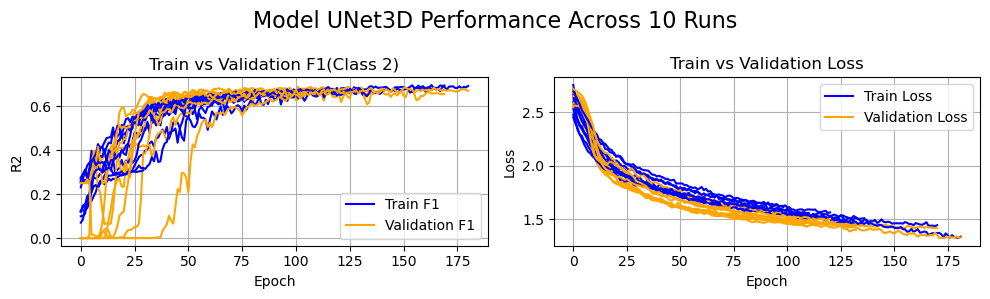

0

In [ ]:
with open(f"./modelos/runs/Classification/tloop_{model_name}_{sp}.json", "r") as file:
    data = json.load(file)
list_of_F1_train = data["list_of_F1_train"]
list_of_F1_val = data["list_of_F1_val"]
list_of_train_loss = data["list_of_train_loss"]
list_of_val_loss = data["list_of_val_loss"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
fig.suptitle(f"Curvas de entrenamiento de {model_name} en {iters} iteraciones", fontsize=12)
for i in range(len(list_of_F1_train) - 1):
    axes[0].plot(list_of_F1_train[i], color="blue")
    axes[0].plot(list_of_F1_val[i], color="orange")
axes[0].plot(list_of_F1_train[-1], color="blue", label="Entrenamiento")
axes[0].plot(list_of_F1_val[-1], color="orange", label="Validación")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("F1")
axes[0].set_title("F1 de entrenamiento vs validación (Clase 2)")
axes[0].grid(True)
axes[0].legend()

for i in range(len(list_of_train_loss) - 1):
    axes[1].plot(list_of_train_loss[i], color="blue")
    axes[1].plot(list_of_val_loss[i], color="orange")
axes[1].plot(list_of_train_loss[-1], color="blue", label="Train Loss")
axes[1].plot(list_of_val_loss[-1], color="orange", label="Validation Loss")

axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
axes[1].set_title("Pérdida de entrenamiento vs validación")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

img_buffer1 = BytesIO()
fig.savefig(img_buffer1, format="png", bbox_inches="tight")
img_buffer1.seek(0)

In [ ]:
def compute_metrics(preds, targets):

    # =====================================================
    # 1. Classification & Segmentation Metrics (Filtered)
    # =====================================================
    valid_idx = ~np.isnan(targets) & ~np.isnan(preds)
    y_true_flat = targets[valid_idx].astype(int)
    y_pred_flat = preds[valid_idx].astype(int)
    
    print("=== Classification Report ===")
    report = pd.DataFrame(classification_report(y_true_flat, y_pred_flat, output_dict=True, labels=[0, 1, 2]), zero_division=0).T
    
    print(report)
    
    iou_per_class = jaccard_score(y_true_flat, y_pred_flat, average=None, labels=[0, 1, 2])
    kappa = cohen_kappa_score(y_true_flat, y_pred_flat)
    
    print("=== Spatial Segmentation Metrics ===")
    print(f"IoU Class 1 (Low CPUE):      {iou_per_class[1]:.3f}")
    print(f"IoU Class 2 (High CPUE):     {iou_per_class[2]:.3f}")
    print(f"Cohen's Kappa Score:         {kappa:.3f}\n")
    # =====================================================
    # Plot: Confusion Matrix
    # =====================================================
    class_labels = ['Nada (0)', 'CPUE bajo(1)', 'CPUE alto (2)']
    cm = pd.DataFrame(confusion_matrix(y_true_flat,y_pred_flat,labels=[0, 1, 2]),index=class_labels,columns=class_labels)
    
    # =====================================================
    # PLOTTING: Spatial Means
    # =====================================================

    y_pred_mean = np.nanmean(preds, axis=0)
    y_true_mean = np.nanmean(targets, axis=0)
    y_true_mean = np.where(np.isnan(y_true_mean), 0, y_true_mean)
    y_pred_mean = np.where(np.isnan(y_pred_mean), 0, y_pred_mean)

    error = y_pred_mean - y_true_mean

    plt.figure(figsize=(12, 4))

    ax1 = plt.subplot(1, 3, 1)
    plt.title("Mean Test Truth")
    plt.imshow(y_true_mean, cmap='viridis')
    plt.colorbar()
    ax1.invert_yaxis()

    ax2 = plt.subplot(1, 3, 2)
    plt.title("Mean Test Prediction")
    plt.imshow(y_pred_mean, cmap='viridis')
    plt.colorbar()
    ax2.invert_yaxis()

    ax3 = plt.subplot(1, 3, 3)
    plt.title("Mean Error (Pred - True)")
    
    vmax = np.nanmax(np.abs(error)) if not np.isnan(error).all() else 1.0
    plt.imshow(error, cmap='coolwarm', norm=CenteredNorm(vcenter=0.0, halfrange=vmax))
    plt.colorbar()
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # =====================================================
    # PLOTTING: Time Series Comparison
    # =====================================================

    y_pred_plot2 = np.nansum(preds, axis=(1, 2))
    y_true_plot2 = np.nansum(targets, axis=(1, 2))
    y_true_plot2 = np.where(np.isnan(y_true_plot2), 0, y_true_plot2)
    y_pred_plot2 = np.where(np.isnan(y_pred_plot2), 0, y_pred_plot2)
    r2_plot2 = r2_score(y_true_plot2, y_pred_plot2)

    return report, iou_per_class, kappa, cm, y_true_plot2, y_pred_plot2, r2_plot2

Iteration 1/10
=== Classification Report ===
              precision    recall  f1-score      support
0              0.803592  0.851117  0.826672  2418.000000
1              0.738636  0.678969  0.707547  1436.000000
2              0.689822  0.660991  0.675099   646.000000
accuracy       0.768889  0.768889  0.768889     0.768889
macro avg      0.744017  0.730359  0.736439  4500.000000
weighted avg   0.766532  0.768889  0.766899  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.547
IoU Class 2 (High CPUE):     0.510
Cohen's Kappa Score:         0.602



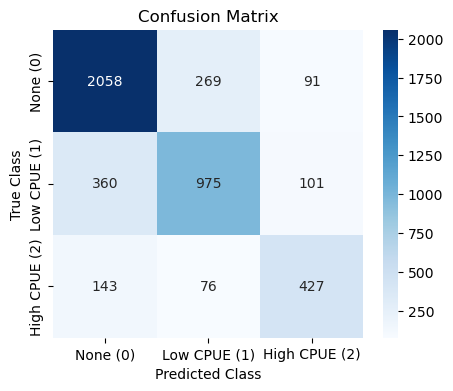

C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:38: RuntimeWarning: Mean of empty slice
  y_pred_mean = np.nanmean(preds, axis=0)
C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:39: RuntimeWarning: Mean of empty slice
  y_true_mean = np.nanmean(targets, axis=0)


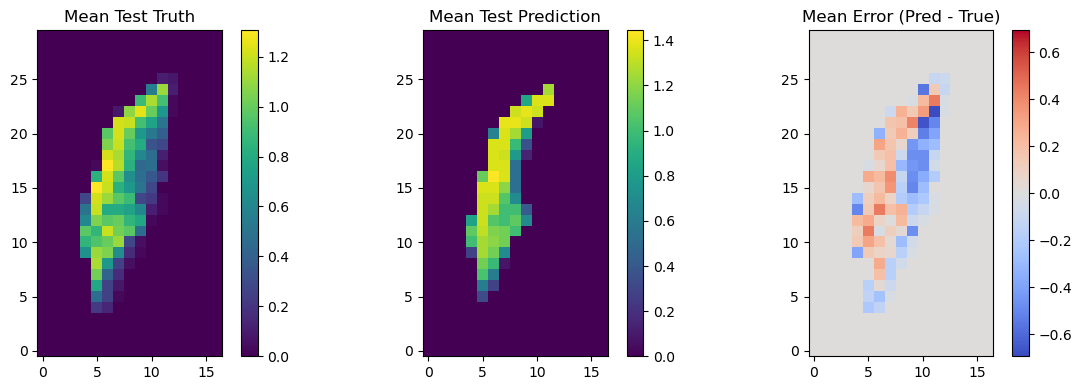

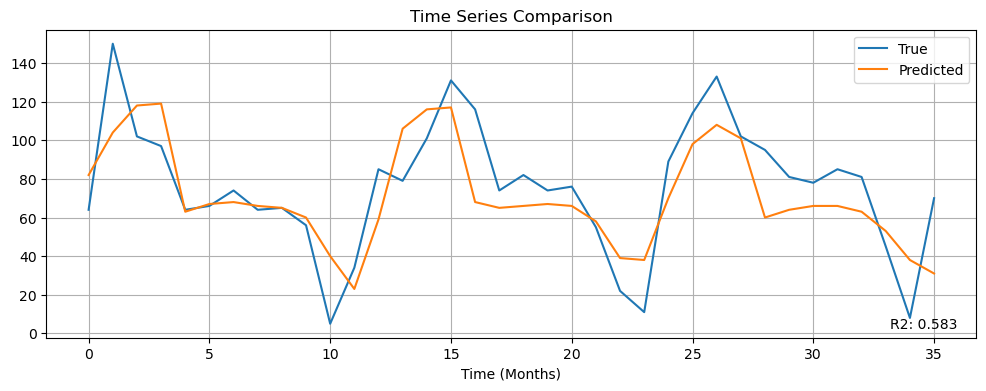

Iteration 2/10
=== Classification Report ===
              precision    recall  f1-score      support
0              0.830895  0.798594  0.814424  2418.000000
1              0.704272  0.734680  0.719155  1436.000000
2              0.660767  0.693498  0.676737   646.000000
accuracy       0.763111  0.763111  0.763111     0.763111
macro avg      0.731978  0.742257  0.736772  4500.000000
weighted avg   0.766065  0.763111  0.764257  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.561
IoU Class 2 (High CPUE):     0.511
Cohen's Kappa Score:         0.602



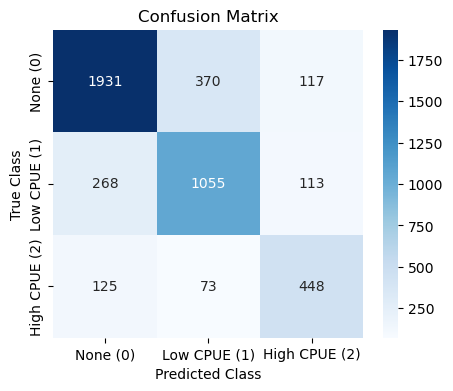

C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:38: RuntimeWarning: Mean of empty slice
  y_pred_mean = np.nanmean(preds, axis=0)
C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:39: RuntimeWarning: Mean of empty slice
  y_true_mean = np.nanmean(targets, axis=0)


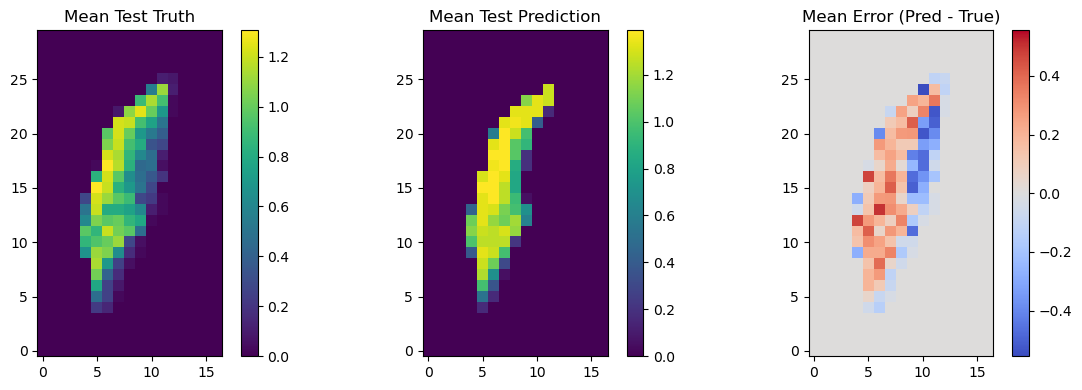

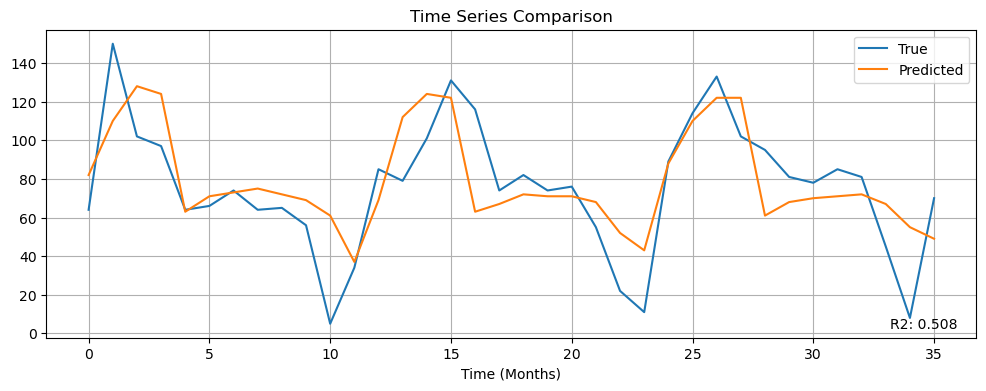

Iteration 3/10
=== Classification Report ===
              precision    recall  f1-score      support
0              0.828442  0.828784  0.828613  2418.000000
1              0.734168  0.734680  0.734424  1436.000000
2              0.683230  0.681115  0.682171   646.000000
accuracy       0.777556  0.777556  0.777556     0.777556
macro avg      0.748613  0.748193  0.748402  4500.000000
weighted avg   0.777512  0.777556  0.777533  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.580
IoU Class 2 (High CPUE):     0.518
Cohen's Kappa Score:         0.622



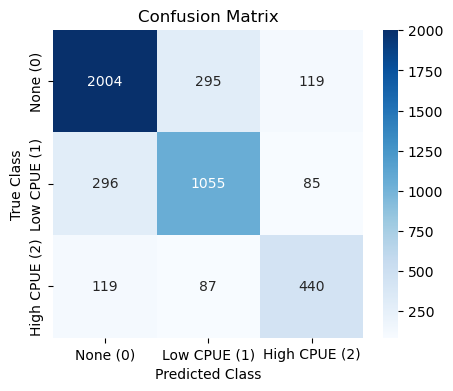

C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:38: RuntimeWarning: Mean of empty slice
  y_pred_mean = np.nanmean(preds, axis=0)
C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:39: RuntimeWarning: Mean of empty slice
  y_true_mean = np.nanmean(targets, axis=0)


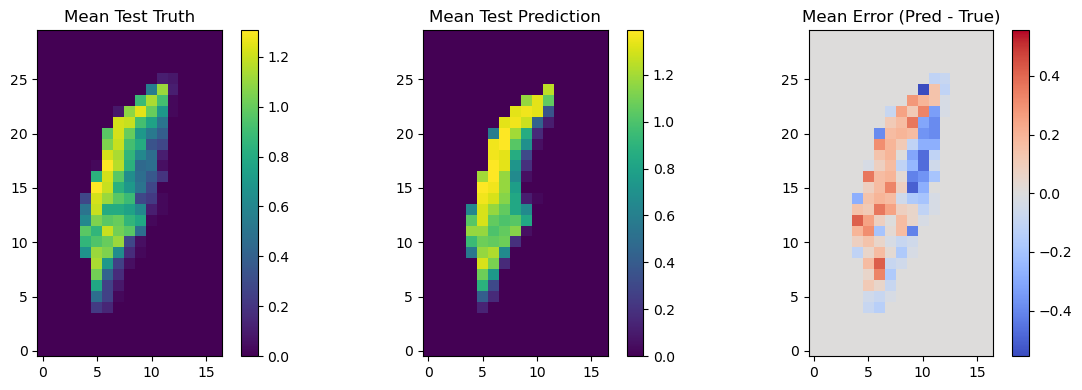

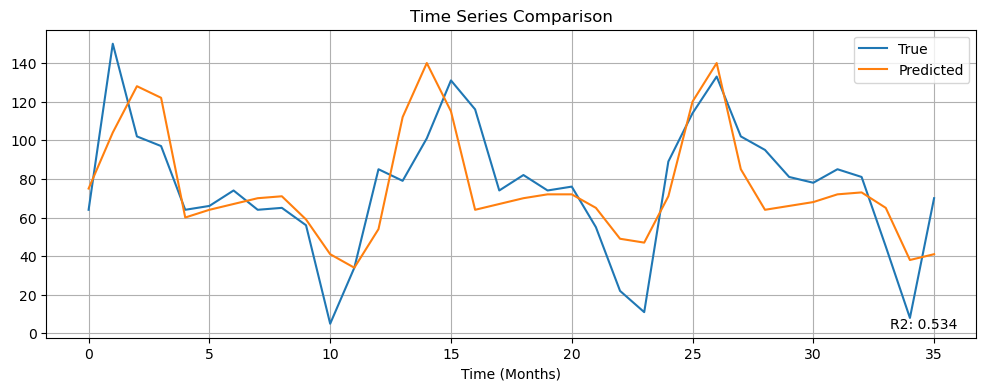

Iteration 4/10
=== Classification Report ===
              precision    recall  f1-score      support
0              0.834119  0.804797  0.819196  2418.000000
1              0.700000  0.740947  0.719892  1436.000000
2              0.683153  0.684211  0.683681   646.000000
accuracy       0.767111  0.767111  0.767111     0.767111
macro avg      0.739091  0.743318  0.740923  4500.000000
weighted avg   0.769648  0.767111  0.768053  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.562
IoU Class 2 (High CPUE):     0.519
Cohen's Kappa Score:         0.607



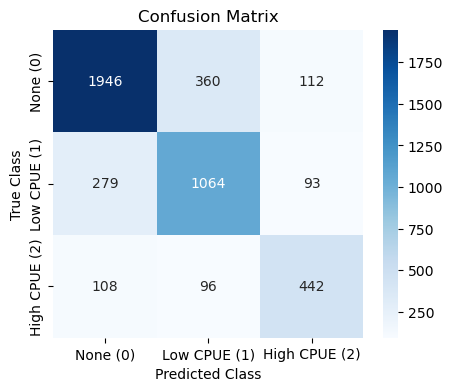

C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:38: RuntimeWarning: Mean of empty slice
  y_pred_mean = np.nanmean(preds, axis=0)
C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:39: RuntimeWarning: Mean of empty slice
  y_true_mean = np.nanmean(targets, axis=0)


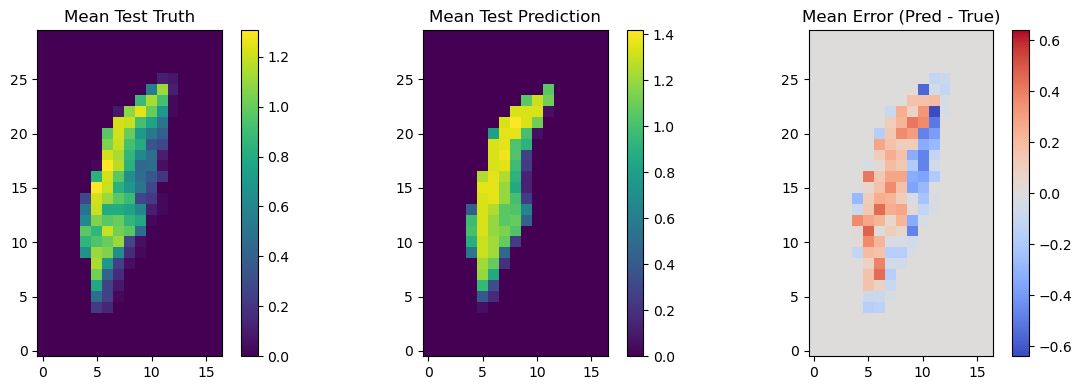

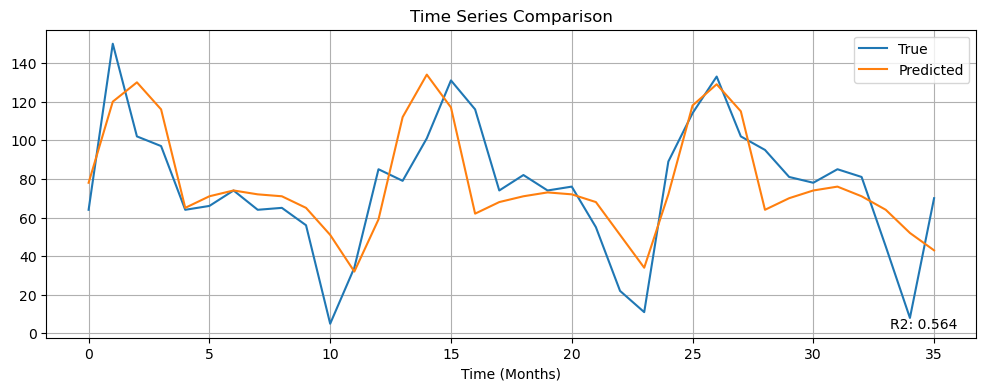

Iteration 5/10
=== Classification Report ===
              precision    recall  f1-score      support
0              0.806786  0.835815  0.821044  2418.000000
1              0.746044  0.689415  0.716612  1436.000000
2              0.676647  0.699690  0.687976   646.000000
accuracy       0.769556  0.769556  0.769556     0.769556
macro avg      0.743159  0.741640  0.741877  4500.000000
weighted avg   0.768720  0.769556  0.768616  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.558
IoU Class 2 (High CPUE):     0.524
Cohen's Kappa Score:         0.606



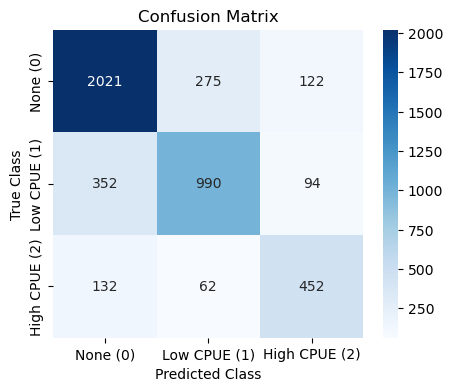

C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:38: RuntimeWarning: Mean of empty slice
  y_pred_mean = np.nanmean(preds, axis=0)
C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:39: RuntimeWarning: Mean of empty slice
  y_true_mean = np.nanmean(targets, axis=0)


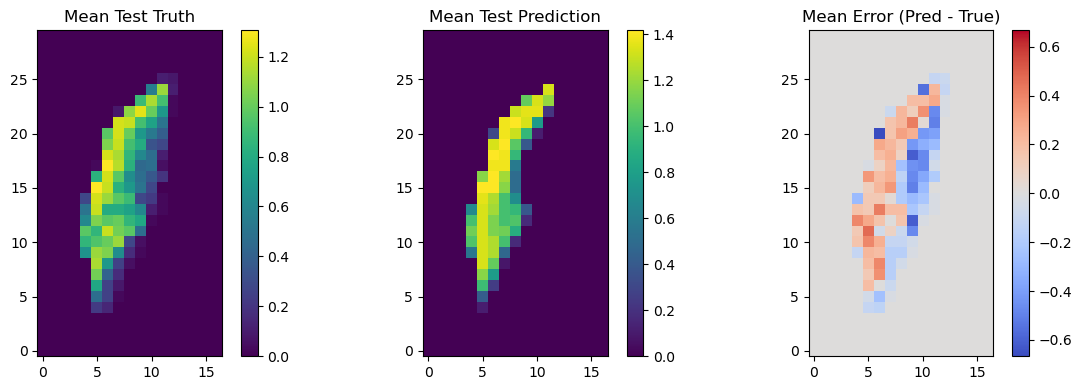

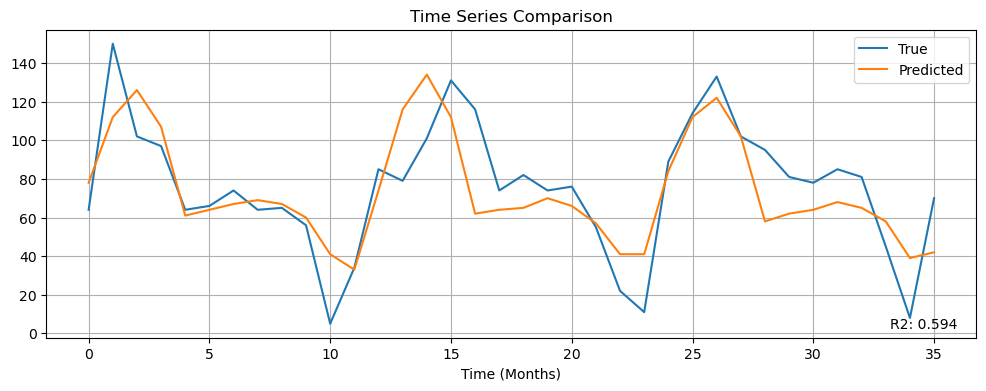

Iteration 6/10
=== Classification Report ===
              precision    recall  f1-score      support
0              0.537333  1.000000  0.699046  2418.000000
1              0.000000  0.000000  0.000000  1436.000000
2              0.000000  0.000000  0.000000   646.000000
accuracy       0.537333  0.537333  0.537333     0.537333
macro avg      0.179111  0.333333  0.233015  4500.000000
weighted avg   0.288727  0.537333  0.375621  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.000
IoU Class 2 (High CPUE):     0.000
Cohen's Kappa Score:         0.000



c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rubar\miniconda3\envs\TFMenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

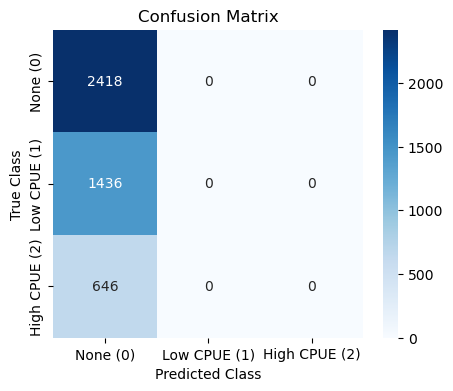

C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:38: RuntimeWarning: Mean of empty slice
  y_pred_mean = np.nanmean(preds, axis=0)
C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:39: RuntimeWarning: Mean of empty slice
  y_true_mean = np.nanmean(targets, axis=0)


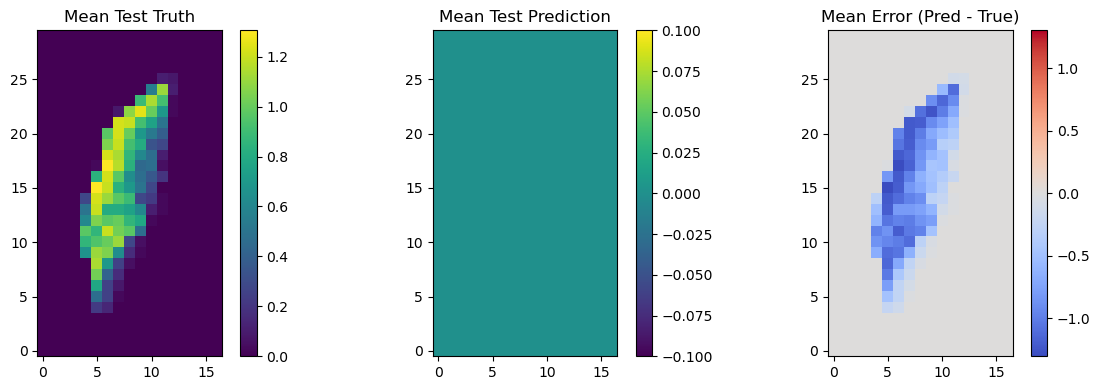

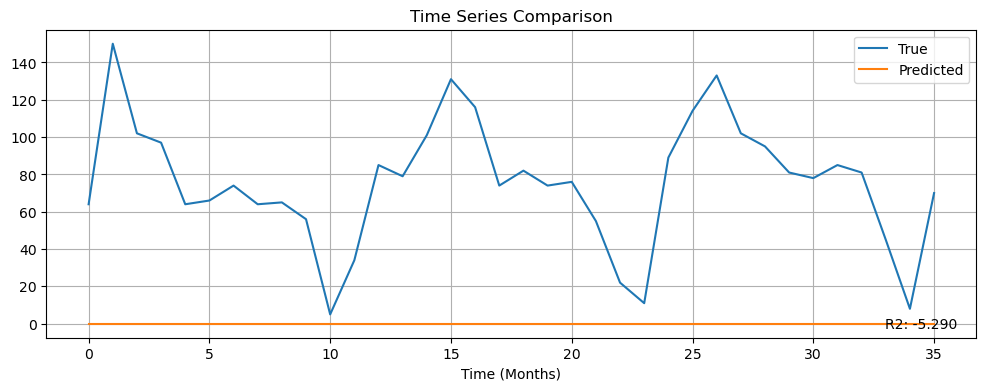

Iteration 7/10
=== Classification Report ===
              precision    recall  f1-score      support
0              0.803579  0.835815  0.819380  2418.000000
1              0.738577  0.686630  0.711656  1436.000000
2              0.687692  0.691950  0.689815   646.000000
accuracy       0.767556  0.767556  0.767556     0.767556
macro avg      0.743283  0.738132  0.740284  4500.000000
weighted avg   0.766200  0.767556  0.766404  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.552
IoU Class 2 (High CPUE):     0.527
Cohen's Kappa Score:         0.602



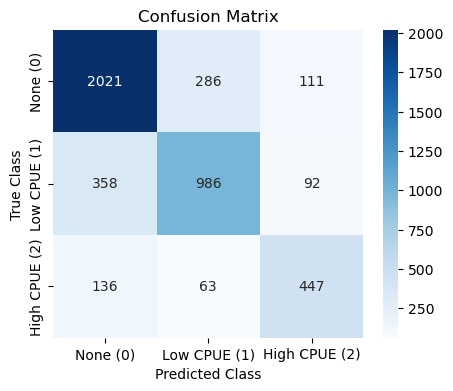

C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:38: RuntimeWarning: Mean of empty slice
  y_pred_mean = np.nanmean(preds, axis=0)
C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:39: RuntimeWarning: Mean of empty slice
  y_true_mean = np.nanmean(targets, axis=0)


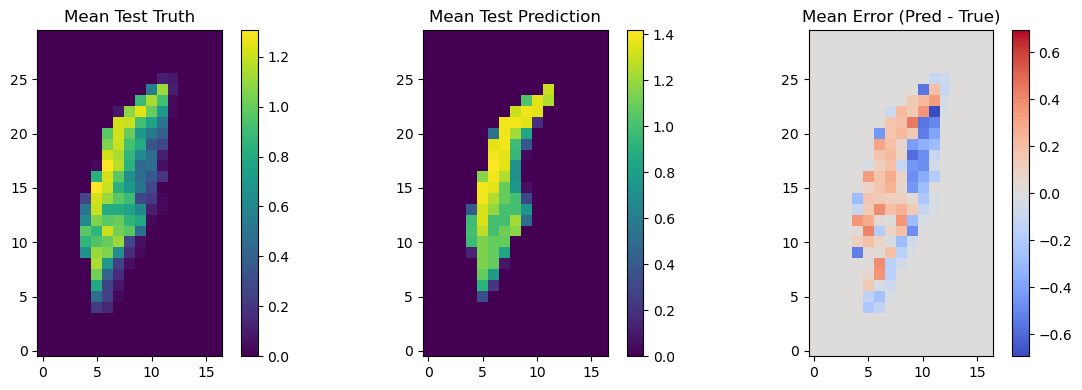

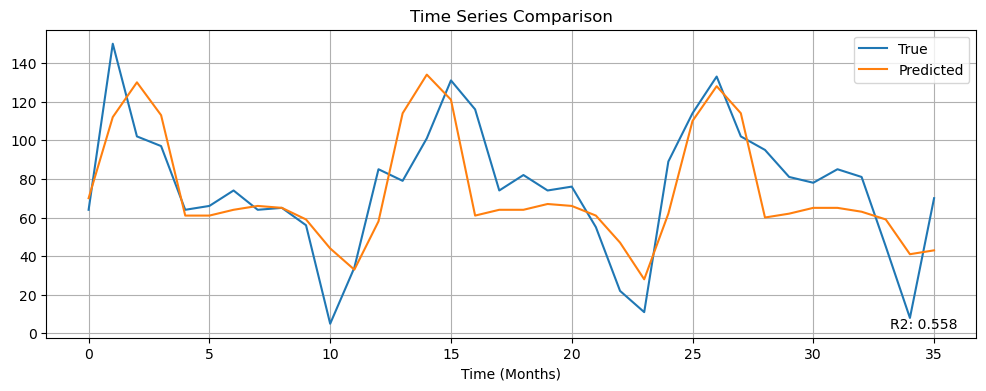

Iteration 8/10
=== Classification Report ===
              precision    recall  f1-score      support
0              0.806860  0.817204  0.811999  2418.000000
1              0.727876  0.687326  0.707020  1436.000000
2              0.641727  0.690402  0.665175   646.000000
accuracy       0.757556  0.757556  0.757556     0.757556
macro avg      0.725488  0.731644  0.728065  4500.000000
weighted avg   0.757950  0.757556  0.757422  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.547
IoU Class 2 (High CPUE):     0.498
Cohen's Kappa Score:         0.589



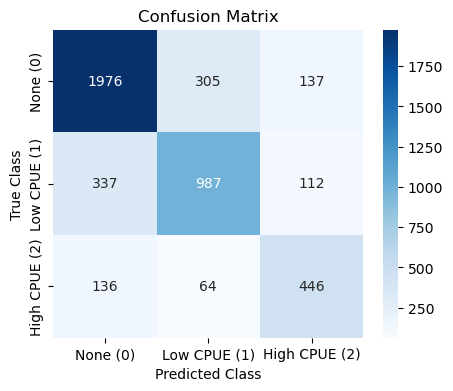

C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:38: RuntimeWarning: Mean of empty slice
  y_pred_mean = np.nanmean(preds, axis=0)
C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:39: RuntimeWarning: Mean of empty slice
  y_true_mean = np.nanmean(targets, axis=0)


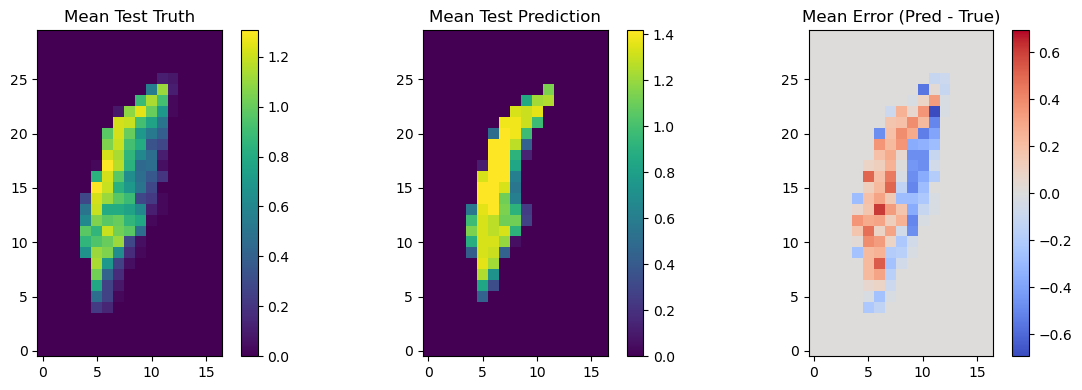

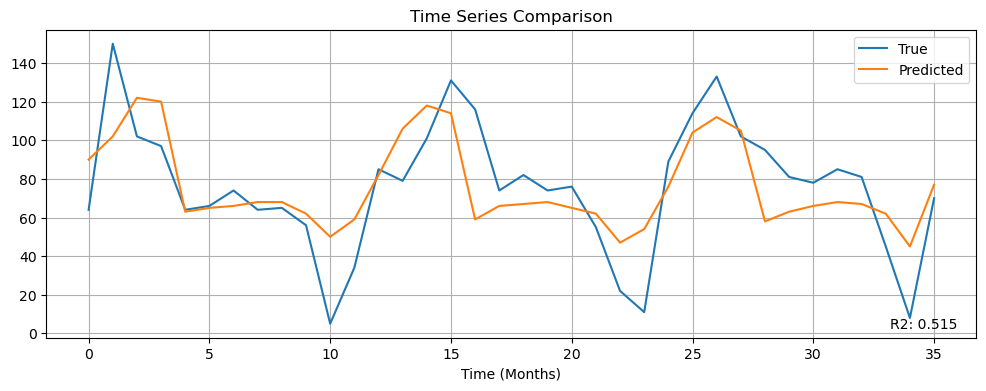

Iteration 9/10
=== Classification Report ===
              precision    recall  f1-score      support
0              0.816466  0.840778  0.828443  2418.000000
1              0.753998  0.689415  0.720262  1436.000000
2              0.661406  0.713622  0.686523   646.000000
accuracy       0.774222  0.774222  0.774222     0.774222
macro avg      0.743957  0.747938  0.745076  4500.000000
weighted avg   0.774272  0.774222  0.773548  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.563
IoU Class 2 (High CPUE):     0.523
Cohen's Kappa Score:         0.616



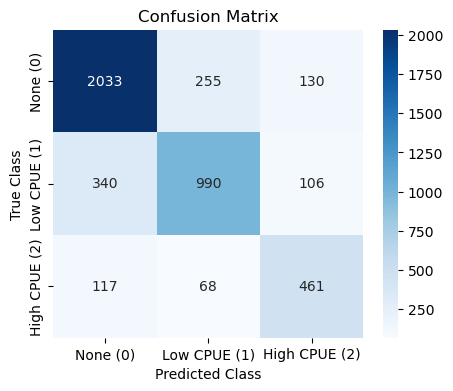

C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:38: RuntimeWarning: Mean of empty slice
  y_pred_mean = np.nanmean(preds, axis=0)
C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:39: RuntimeWarning: Mean of empty slice
  y_true_mean = np.nanmean(targets, axis=0)


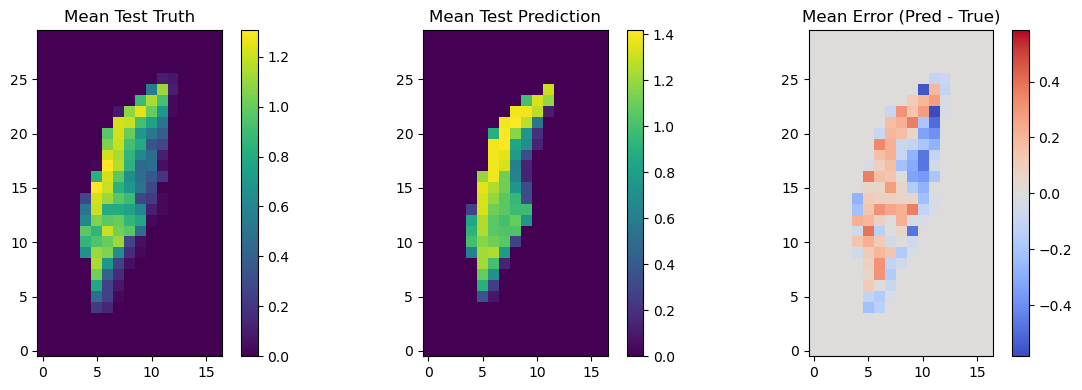

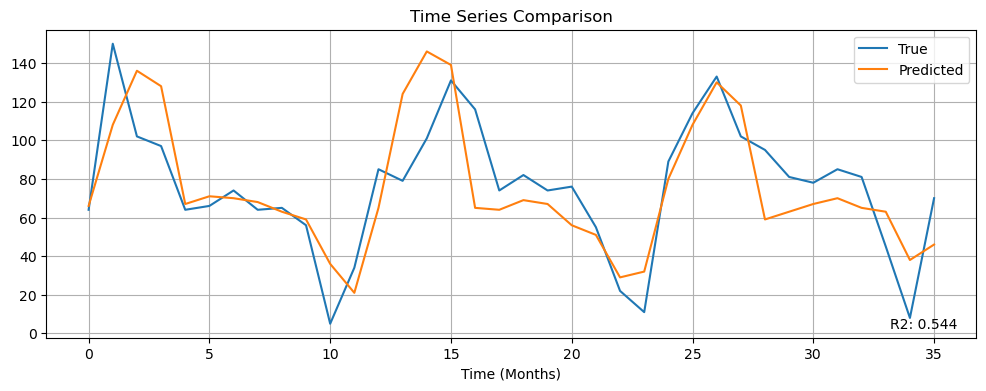

Iteration 10/10
=== Classification Report ===
              precision    recall  f1-score      support
0              0.809505  0.831266  0.820241  2418.000000
1              0.736920  0.696379  0.716076  1436.000000
2              0.674242  0.688854  0.681470   646.000000
accuracy       0.767778  0.767778  0.767778     0.767778
macro avg      0.740222  0.738833  0.739262  4500.000000
weighted avg   0.766924  0.767778  0.767079  4500.000000
=== Spatial Segmentation Metrics ===
IoU Class 1 (Low CPUE):      0.558
IoU Class 2 (High CPUE):     0.517
Cohen's Kappa Score:         0.604



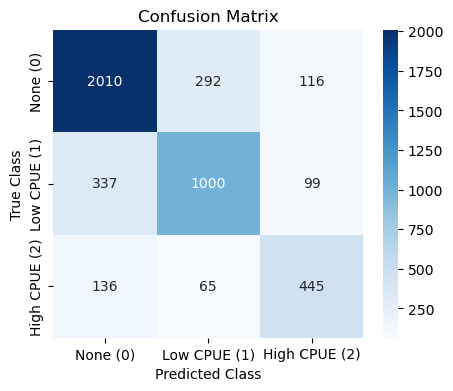

C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:38: RuntimeWarning: Mean of empty slice
  y_pred_mean = np.nanmean(preds, axis=0)
C:\Users\rubar\AppData\Local\Temp\ipykernel_9404\1698352923.py:39: RuntimeWarning: Mean of empty slice
  y_true_mean = np.nanmean(targets, axis=0)


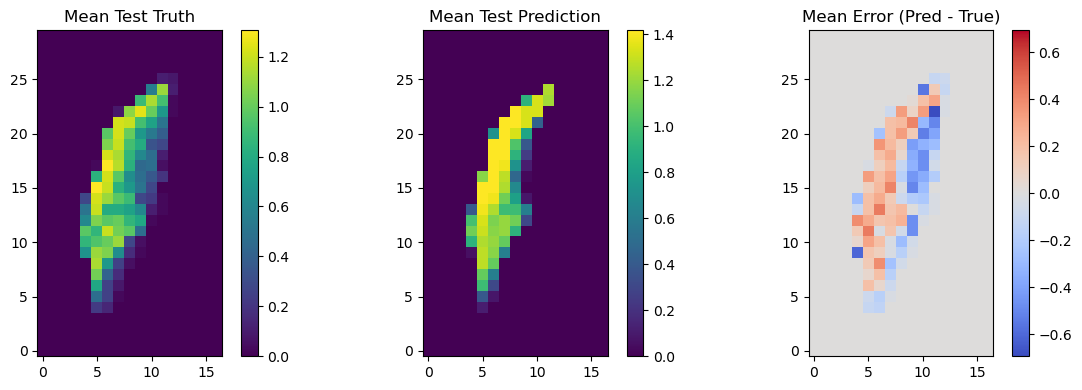

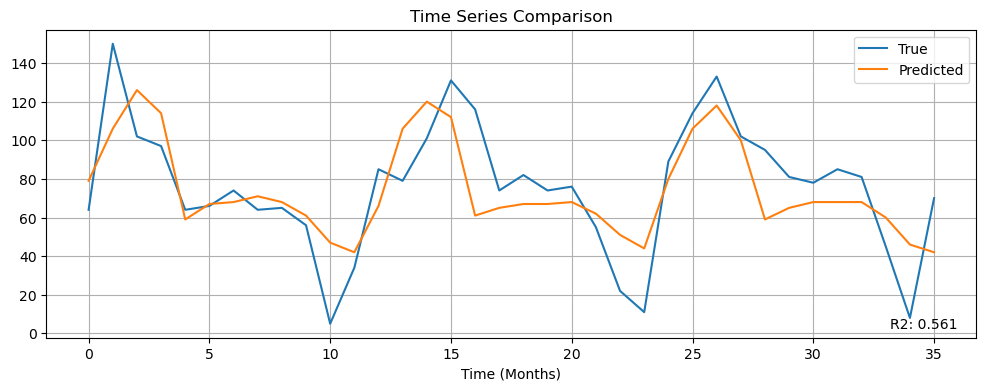

,IoU
Class 0,0.681 ± 0.051
Class 1,0.503 ± 0.177
Class 2,0.465 ± 0.163


,Mean ± Std
Cohen's Kappa,0.545 ± 0.192
Aggregated R2,-0.033 ± 1.847


,precision,recall,f1-score,support
0,0.788 ± 0.089,0.844 ± 0.057,0.809 ± 0.039,2418.000 ± 0.000
1,0.658 ± 0.232,0.634 ± 0.224,0.645 ± 0.227,1436.000 ± 0.000
2,0.606 ± 0.213,0.620 ± 0.218,0.613 ± 0.215,646.000 ± 0.000
accuracy,0.745 ± 0.073,0.745 ± 0.073,0.745 ± 0.073,0.745 ± 0.073
macro avg,0.684 ± 0.177,0.700 ± 0.129,0.689 ± 0.160,4500.000 ± 0.000
weighted avg,0.720 ± 0.152,0.745 ± 0.073,0.729 ± 0.124,4500.000 ± 0.000


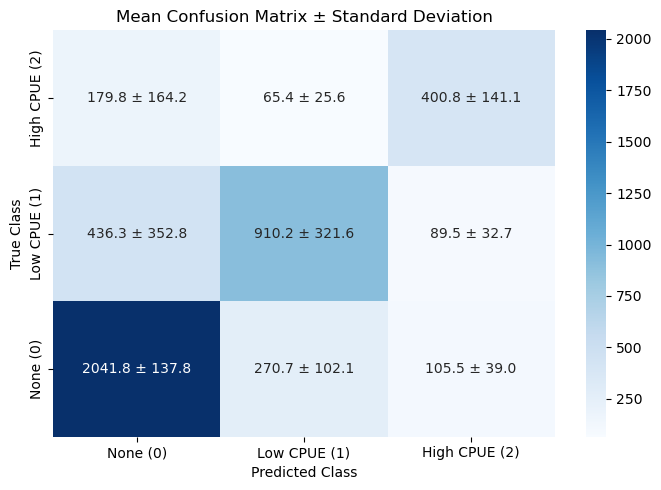

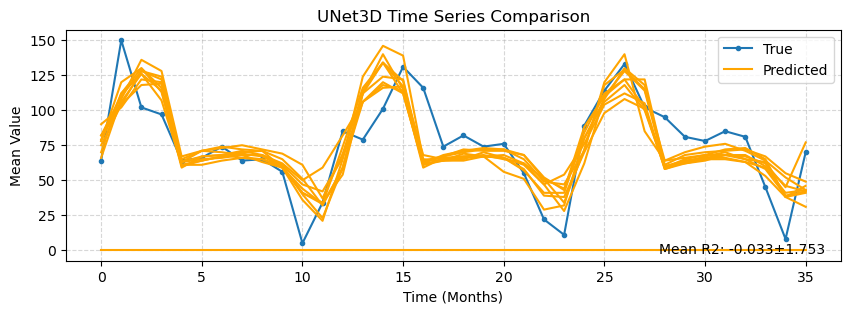

In [ ]:
reports = []
ious = []
kappas = []
y_preds_plot=[]
confusion_matrices = []
r2s_plot = []
for i in range(iters):
    print(f"Iteration {i+1}/{iters}")
    model_path = f"./modelos/runs/Classification/{model_name}_{i+1}.pth"
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    all_preds = []
    all_targets = []
    all_masks = []  

    with torch.no_grad():
        for x, y, m in test_loader:
            x = x.to(device)
            
            logits = model(x)
            # Get the predicted class index (B, H, W)
            pred = logits.argmax(dim=1)    
            
            # Keep them as 2D batches and move to CPU
            all_preds.append(pred.cpu().numpy())
            all_targets.append(y.numpy())
            all_masks.append(m.numpy())


    preds_all = np.concatenate(all_preds, axis=0).astype(float)
    targets_all = np.concatenate(all_targets, axis=0).astype(float)
    masks_all = np.concatenate(all_masks, axis=0)

    preds_all[masks_all == 0] = np.nan
    targets_all[masks_all == 0] = np.nan

    report, iou_per_class, kappa, cm, y_true_plot, y_pred_plot, r2_plot = compute_metrics(preds_all, targets_all)

    reports.append(report)
    ious.append(iou_per_class)
    kappas.append(kappa)
    y_preds_plot.append(y_pred_plot)
    confusion_matrices.append(cm)
    r2s_plot.append(r2_plot)

#get summary statistics and save

ious_df = pd.DataFrame(ious, columns=["Clase 0", "Clase 1", "Clase 2"])
iou_mean_std = pd.DataFrame({
    "IoU": ious_df.apply(
        lambda x: f"{x.mean():.3f}±{x.std():.3f}"
    )
})

display(iou_mean_std)

metrics_df = pd.DataFrame({
    "Cohen's Kappa": kappas,
    "R2 agregado": r2s_plot
})

metrics_mean_std = pd.DataFrame({
    "Mean ± Std": metrics_df.apply(
        lambda x: f"{x.mean():.3f}±{x.std():.3f}"
    )
})

display(metrics_mean_std)

report_mean_std = (
    pd.concat(reports, keys=range(len(reports)))
    .groupby(level=1)
    .agg(lambda x: f"{x.mean():.3f}±{x.std():.3f}")
)

display(report_mean_std)

cm_mean = (
    pd.concat(confusion_matrices, keys=range(len(confusion_matrices)))
    .groupby(level=1)
    .mean()
)

cm_std = (
    pd.concat(confusion_matrices, keys=range(len(confusion_matrices)))
    .groupby(level=1)
    .std()
)

cm_annotations = cm_mean.combine(
    cm_std,
    lambda mean, std: mean.map(lambda x: f"{x:.1f}")
                      + "±"
                      + std.map(lambda x: f"{x:.1f}")
)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_mean, annot=cm_annotations, fmt="", cmap="Blues", xticklabels=cm_mean.columns,yticklabels=cm_mean.index)

plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.title("Matriz de confusión promedio")
plt.tight_layout()
img_buffer3 = BytesIO()
plt.savefig(img_buffer3, format="png", bbox_inches="tight")
img_buffer3.seek(0)

plt.show()

plt.figure(figsize=(10, 3))
plt.plot(y_true_plot, label="Real", marker='o', markersize=3)
for i in range(len(y_preds_plot)-1):
    plt.plot(y_preds_plot[i], color="orange")
plt.plot(y_preds_plot[i+1], color="orange", label="Predicho")

plt.annotate(f"R2 promedio: {np.array(r2s_plot).mean():.3f}±{np.array(r2s_plot).std():.3f}", xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom')
plt.xlabel("Tiempo (Meses)")
plt.ylabel("Clases agregadas")
plt.title(f"Serie temporal de {model_name}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

img_buffer2 = BytesIO()
plt.savefig(img_buffer2, format="png", bbox_inches="tight")
img_buffer2.seek(0)
plt.show()

#save to excel
# save everyhtng to a excel workbook
with pd.ExcelWriter("./modelos/resultados/Class/DL_cla.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    sheet_name = f"{model_name}_{sp}"
    report_mean_std.to_excel(writer, sheet_name=sheet_name, startrow=1)

with pd.ExcelWriter("./modelos/resultados/Class/DL_cla.xlsx", engine="openpyxl", mode="a", if_sheet_exists="overlay") as writer:
    sheet_name = f"{model_name}_{sp}"
    iou_mean_std.to_excel(writer, sheet_name=sheet_name, startrow=len(report_mean_std) + 3)
    metrics_mean_std.to_excel(writer, sheet_name=sheet_name, startrow=len(report_mean_std) + len(iou_mean_std) + 6, index=False)
    ws = writer.sheets[sheet_name]
    img1 = Image(img_buffer1)
    ws.add_image(img1, f"N1")
    img2 = Image(img_buffer2)
    ws.add_image(img2, f"N21")
    img3 = Image(img_buffer3)
    ws.add_image(img3, f"N41")


In [42]:
ious

[array([0.70455324, 0.54744526, 0.50954654]),
 array([0.68694415, 0.56146887, 0.51141553]),
 array([0.70737734, 0.58030803, 0.51764706]),
 array([0.69376114, 0.56236786, 0.51938895]),
 array([0.69641626, 0.55837563, 0.52436195]),
 array([0.53733333, 0.        , 0.        ]),
 array([0.69402473, 0.55238095, 0.52650177]),
 array([0.68350052, 0.5468144 , 0.49832402]),
 array([0.70713043, 0.56281978, 0.52267574]),
 array([0.69526116, 0.55772448, 0.51684088])]